# Rotated Weight Group Distribution

학습된 `R_*.bin` rotation을 weight에 적용한 뒤, BFP group 단위로 weight 분포를 확인하는 노트북입니다.

기본적으로 확인하는 값은 다음입니다.

- `group_absmax`: group 내부 `abs(weight)`의 최댓값
- `group_mean_abs`: group 내부 평균 절댓값
- `group_std`: group 내부 표준편차
- original weight와 rotated weight의 group absmax 요약 비교

기본 분석 대상은 BFP weight quantization이 실제 적용되는 projection weight입니다. `lm_head`는 기본 제외입니다.

In [1]:
# ===== User config =====
MODEL = "meta-llama/Llama-2-7b-hf"
EXPERIMENT_DIR = "/home/irteam/shmin/SpinBFP/SpinQuant/bfp_runs/Llama-2-7b-hf"

W_BITS = 4 
A_BITS = 4
KV_BITS = 4
GROUP_SIZE = 32

# Rotation filename suffix follows bfp_refactor: R_{w}_{a}_{kv}_{W_DOWN}{QK}.bin
# -1 means Full Hadamard (F), positive value means Block Hadamard (B).
W_DOWN_HAD_GROUP_SIZE = -1
QK_HAD_GROUP_SIZE = -1
ROTATION_PATH = None  # None이면 EXPERIMENT_DIR/R_* 파일을 자동 탐색합니다.

MODEL_DTYPE = "auto"  # auto, fp16, bf16, fp32
ROTATION_COMPUTE_DTYPE = "fp64"  # 기존 eval과 맞추려면 fp64, 메모리 줄이려면 fp32
DEVICE = "cuda:1"  # cuda or cpu

# None이면 전체 layer. 테스트할 때는 1~2로 줄여서 먼저 확인하세요.
MAX_LAYERS = None
MODULES = "all"  # all or comma-separated: q_proj,k_proj,v_proj,o_proj,gate_proj,up_proj,down_proj
INCLUDE_LM_HEAD = False

HIST_BINS = 128
TOP_K = 20
OUTPUT_DIR = None  # None이면 EXPERIMENT_DIR/weight_distribution/{rotation_stem}

In [2]:
from pathlib import Path
from types import SimpleNamespace
import sys

import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoConfig, AutoModelForCausalLM

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "bfp_refactor").exists():
    # If the notebook is opened from bfp_refactor/notebooks, move two levels up.
    REPO_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(REPO_ROOT))

import importlib
import bfp_refactor.analyze_rotated_weight_distribution as weight_dist
importlib.reload(weight_dist)
from bfp_refactor.analyze_rotated_weight_distribution import (
    effective_weight_llama,
    effective_weight_opt,
    default_output_dir,
    find_rotation_path,
    group_summary,
    hadamard_type,
    iter_llama_modules,
    iter_opt_modules,
    module_filter,
    r2_key,
    resolve_compute_dtype,
    resolve_dtype,
    rotation_filename,
)

In [3]:
args = SimpleNamespace(
    model=MODEL,
    experiment_dir=EXPERIMENT_DIR,
    rotation_path=ROTATION_PATH,
    output_dir=OUTPUT_DIR,
    access_token=None,
    w_bits=W_BITS,
    a_bits=A_BITS,
    kv_bits=KV_BITS,
    group_size=GROUP_SIZE,
    w_down_had_group_size=W_DOWN_HAD_GROUP_SIZE,
    qk_had_group_size=QK_HAD_GROUP_SIZE,
    dtype=MODEL_DTYPE,
    rotation_compute_dtype=ROTATION_COMPUTE_DTYPE,
    device=DEVICE,
    modules=MODULES,
    max_layers=MAX_LAYERS,
    hist_bins=HIST_BINS,
    top_k=TOP_K,
    include_lm_head=INCLUDE_LM_HEAD,
    no_rotate=False,
)

rotation_path = find_rotation_path(args)
output_dir = default_output_dir(args, rotation_path)
output_dir.mkdir(parents=True, exist_ok=True)

print("Expected rotation filename:", rotation_filename(args))
print("Rotation path:", rotation_path)
print("Output dir:", output_dir)

Expected rotation filename: R_4_4_4_FF.bin
Rotation path: /home/irteam/shmin/SpinBFP/SpinQuant/bfp_runs/Llama-2-7b-hf/R_4_4_4_FF.bin
Output dir: /home/irteam/shmin/SpinBFP/SpinQuant/bfp_runs/Llama-2-7b-hf/weight_distribution/R_4_4_4_FF


In [4]:
# This cell rebuilds args/rotation_path every time, so changing the config above is safe.
args = SimpleNamespace(
    model=MODEL,
    experiment_dir=EXPERIMENT_DIR,
    rotation_path=ROTATION_PATH,
    output_dir=OUTPUT_DIR,
    access_token=None,
    w_bits=W_BITS,
    a_bits=A_BITS,
    kv_bits=KV_BITS,
    group_size=GROUP_SIZE,
    w_down_had_group_size=W_DOWN_HAD_GROUP_SIZE,
    qk_had_group_size=QK_HAD_GROUP_SIZE,
    dtype=MODEL_DTYPE,
    rotation_compute_dtype=ROTATION_COMPUTE_DTYPE,
    device=DEVICE,
    modules=MODULES,
    max_layers=MAX_LAYERS,
    hist_bins=HIST_BINS,
    top_k=TOP_K,
    include_lm_head=INCLUDE_LM_HEAD,
    no_rotate=False,
)

rotation_path = find_rotation_path(args)
output_dir = default_output_dir(args, rotation_path)
output_dir.mkdir(parents=True, exist_ok=True)

device = torch.device(DEVICE if DEVICE is not None else ("cuda" if torch.cuda.is_available() else "cpu"))
dtype = resolve_dtype(MODEL_DTYPE, MODEL)
compute_dtype = resolve_compute_dtype(ROTATION_COMPUTE_DTYPE)

hf_config = AutoConfig.from_pretrained(MODEL)
print("model_type:", hf_config.model_type)
print("device:", device)
print("model dtype:", dtype)
print("rotation compute dtype:", compute_dtype)
print("rotation path:", rotation_path)
print("output dir:", output_dir)

rotations = torch.load(rotation_path, map_location="cpu")
r1_cpu = rotations["R1"]
expected_hidden = getattr(hf_config, "hidden_size", None)
if expected_hidden is not None and tuple(r1_cpu.shape) != (expected_hidden, expected_hidden):
    raise ValueError(
        f"Rotation R1 shape {tuple(r1_cpu.shape)} does not match model hidden size "
        f"{expected_hidden}. Check MODEL/EXPERIMENT_DIR/ROTATION_PATH."
    )
r1 = r1_cpu.to(device=device)
print("R1:", tuple(r1.shape), r1.dtype)
print("num R2:", sum(1 for key in rotations if key.endswith("self_attn.R2")))


model_type: llama
device: cuda:1
model dtype: torch.float16
rotation compute dtype: torch.float64
rotation path: /home/irteam/shmin/SpinBFP/SpinQuant/bfp_runs/Llama-2-7b-hf/R_4_4_4_FF.bin
output dir: /home/irteam/shmin/SpinBFP/SpinQuant/bfp_runs/Llama-2-7b-hf/weight_distribution/R_4_4_4_FF
R1: (4096, 4096) torch.float32
num R2: 32


In [5]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    config=hf_config,
    torch_dtype=dtype,
    low_cpu_mem_usage=True,
).eval().to(device)

if hf_config.model_type == "llama":
    module_iter = iter_llama_modules(model, INCLUDE_LM_HEAD)
    apply_effective_weight = effective_weight_llama
elif hf_config.model_type == "opt":
    module_iter = iter_opt_modules(model, INCLUDE_LM_HEAD)
    apply_effective_weight = effective_weight_opt
else:
    raise ValueError(f"Unsupported model_type: {hf_config.model_type}")

selected_modules = module_filter(MODULES)
print("model loaded")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

model loaded


In [6]:
def analyze_one_module(layer_idx, module_name, linear):
    weight = linear.weight.detach().to(device)
    if weight.shape[-1] % GROUP_SIZE != 0:
        raise ValueError(f"{layer_idx}.{module_name}: last dim {weight.shape[-1]} is not divisible by {GROUP_SIZE}")

    layer_r2 = None
    if isinstance(layer_idx, int):
        key = r2_key(hf_config.model_type, layer_idx)
        if key in rotations:
            layer_r2 = rotations[key].to(device=device)

    rotated = apply_effective_weight(
        weight,
        module_name,
        r1,
        layer_r2,
        rotate=True,
        compute_dtype=compute_dtype,
    )

    orig_stats, _, _, _ = group_summary(weight, GROUP_SIZE)
    rot_stats, group_absmax, group_mean_abs, group_std = group_summary(rotated, GROUP_SIZE)

    row = {
        "layer": layer_idx,
        "module": module_name,
        "shape": "x".join(str(v) for v in weight.shape),
        "groups_per_row": weight.shape[-1] // GROUP_SIZE,
        "orig_absmax_mean": orig_stats["group_absmax_mean"],
        "orig_absmax_p99": orig_stats["group_absmax_q99"],
        "orig_absmax_max": orig_stats["group_absmax_max"],
        "rot_absmax_mean": rot_stats["group_absmax_mean"],
        "rot_absmax_p50": rot_stats["group_absmax_q50"],
        "rot_absmax_p90": rot_stats["group_absmax_q90"],
        "rot_absmax_p95": rot_stats["group_absmax_q95"],
        "rot_absmax_p99": rot_stats["group_absmax_q99"],
        "rot_absmax_max": rot_stats["group_absmax_max"],
        "ratio_mean_rot_over_orig": rot_stats["group_absmax_mean"] / orig_stats["group_absmax_mean"],
    }
    return row, group_absmax.detach().float().cpu(), group_mean_abs.detach().float().cpu(), group_std.detach().float().cpu()

In [7]:
summary_rows = []
group_cache = {}

with torch.inference_mode():
    for layer_idx, module_name, linear in module_iter:
        if MAX_LAYERS is not None and isinstance(layer_idx, int) and layer_idx >= MAX_LAYERS:
            continue
        if selected_modules is not None and module_name not in selected_modules:
            continue

        row, group_absmax, group_mean_abs, group_std = analyze_one_module(layer_idx, module_name, linear)
        summary_rows.append(row)
        group_cache[(layer_idx, module_name)] = {
            "group_absmax": group_absmax,
            "group_mean_abs": group_mean_abs,
            "group_std": group_std,
        }
        print(f"{layer_idx}.{module_name}: mean={row['rot_absmax_mean']:.6g}, p99={row['rot_absmax_p99']:.6g}, max={row['rot_absmax_max']:.6g}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

summary_df = pd.DataFrame(summary_rows)
summary_df

0.q_proj: mean=0.0281492, p99=0.0852051, max=0.186279
0.k_proj: mean=0.0326905, p99=0.083374, max=0.192383
0.v_proj: mean=0.0245474, p99=0.0613403, max=0.109192
0.o_proj: mean=0.0156029, p99=0.0410767, max=0.0751953
0.gate_proj: mean=0.0382277, p99=0.0627441, max=0.317139
0.up_proj: mean=0.0377591, p99=0.0593567, max=0.116272
0.down_proj: mean=0.0395062, p99=0.0608826, max=0.1026
1.q_proj: mean=0.0527795, p99=0.161865, max=0.317871
1.k_proj: mean=0.0533611, p99=0.162354, max=0.300293
1.v_proj: mean=0.0226214, p99=0.0444336, max=0.0748291
1.o_proj: mean=0.0179293, p99=0.0390015, max=0.0629883
1.gate_proj: mean=0.0424407, p99=0.067749, max=0.562012
1.up_proj: mean=0.0401919, p99=0.0620422, max=0.436768
1.down_proj: mean=0.0408584, p99=0.0627441, max=0.09729
2.q_proj: mean=0.0578975, p99=0.128418, max=0.217285
2.k_proj: mean=0.0594789, p99=0.141479, max=0.262451
2.v_proj: mean=0.0335236, p99=0.0526733, max=0.0786133
2.o_proj: mean=0.0325429, p99=0.0511169, max=0.0793457
2.gate_proj: mean=

,layer,module,shape,groups_per_row,orig_absmax_mean,orig_absmax_p99,orig_absmax_max,rot_absmax_mean,rot_absmax_p50,rot_absmax_p90,rot_absmax_p95,rot_absmax_p99,rot_absmax_max,ratio_mean_rot_over_orig
0,0,q_proj,4096x4096,128,0.038349,0.181641,0.773438,0.028149,0.024124,0.047546,0.058044,0.085205,0.186279,0.734030
1,0,k_proj,4096x4096,128,0.042913,0.165039,0.816406,0.032691,0.029892,0.051880,0.060669,0.083374,0.192383,0.761779
2,0,v_proj,4096x4096,128,0.024620,0.064941,0.134766,0.024547,0.022034,0.036133,0.044983,0.061340,0.109192,0.997046
3,0,o_proj,4096x4096,128,0.017784,0.047363,0.451172,0.015603,0.013725,0.024185,0.030670,0.041077,0.075195,0.877359
4,0,gate_proj,11008x4096,128,0.038336,0.064453,0.890625,0.038228,0.037170,0.048676,0.052826,0.062744,0.317139,0.997171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,31,v_proj,4096x4096,128,0.044819,0.073242,0.390625,0.044561,0.043488,0.057129,0.061829,0.071777,0.111938,0.994247
220,31,o_proj,4096x4096,128,0.044406,0.072754,1.312500,0.045020,0.044098,0.057526,0.062073,0.071594,0.109070,1.013842
221,31,gate_proj,11008x4096,128,0.049902,0.095703,0.380859,0.049685,0.047455,0.065308,0.073425,0.093323,0.275879,0.995658
222,31,up_proj,11008x4096,128,0.047449,0.078125,0.753906,0.047198,0.046112,0.060059,0.064941,0.076355,0.395752,0.994699


In [8]:
summary_csv = output_dir / "notebook_summary.csv"
summary_df.to_csv(summary_csv, index=False)
summary_csv

PosixPath('/home/irteam/shmin/SpinBFP/SpinQuant/bfp_runs/Llama-2-7b-hf/weight_distribution/R_4_4_4_FF/notebook_summary.csv')

## Module별 group absmax 요약

`rot_absmax_*`가 rotation 적용 후 weight를 `GROUP_SIZE` 단위로 나눴을 때의 absmax 분포입니다.

In [9]:
cols = [
    "layer", "module", "shape", "rot_absmax_mean", "rot_absmax_p50", "rot_absmax_p90",
    "rot_absmax_p95", "rot_absmax_p99", "rot_absmax_max", "ratio_mean_rot_over_orig"
]
summary_df[cols].sort_values(["layer", "module"]).head(30)

,layer,module,shape,rot_absmax_mean,rot_absmax_p50,rot_absmax_p90,rot_absmax_p95,rot_absmax_p99,rot_absmax_max,ratio_mean_rot_over_orig
6,0,down_proj,4096x11008,0.039506,0.038696,0.049530,0.053223,0.060883,0.102600,0.995904
4,0,gate_proj,11008x4096,0.038228,0.037170,0.048676,0.052826,0.062744,0.317139,0.997171
1,0,k_proj,4096x4096,0.032691,0.029892,0.051880,0.060669,0.083374,0.192383,0.761779
3,0,o_proj,4096x4096,0.015603,0.013725,0.024185,0.030670,0.041077,0.075195,0.877359
0,0,q_proj,4096x4096,0.028149,0.024124,0.047546,0.058044,0.085205,0.186279,0.734030
5,0,up_proj,11008x4096,0.037759,0.036926,0.047791,0.051544,0.059357,0.116272,0.996214
2,0,v_proj,4096x4096,0.024547,0.022034,0.036133,0.044983,0.061340,0.109192,0.997046
13,1,down_proj,4096x11008,0.040858,0.040039,0.051178,0.054962,0.062744,0.097290,0.997499
11,1,gate_proj,11008x4096,0.042441,0.041351,0.053345,0.057587,0.067749,0.562012,0.996685
8,1,k_proj,4096x4096,0.053361,0.041626,0.104553,0.125488,0.162354,0.300293,0.936788


## 전체 module 요약 plot

plot_df = summary_df.copy()
plot_df["layer_module"] = plot_df["layer"].astype(str) + "." + plot_df["module"]

plt.figure(figsize=(14, 5))
plt.plot(plot_df["rot_absmax_mean"].values, label="rot mean")
plt.plot(plot_df["rot_absmax_p99"].values, label="rot p99")
plt.plot(plot_df["rot_absmax_max"].values, label="rot max", alpha=0.7)
plt.yscale("log")
plt.xlabel("module index")
plt.ylabel("group absmax")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 특정 layer/module의 group 분포 보기

아래 `TARGET_LAYER`, `TARGET_MODULE`을 바꿔가면서 확인하면 됩니다.

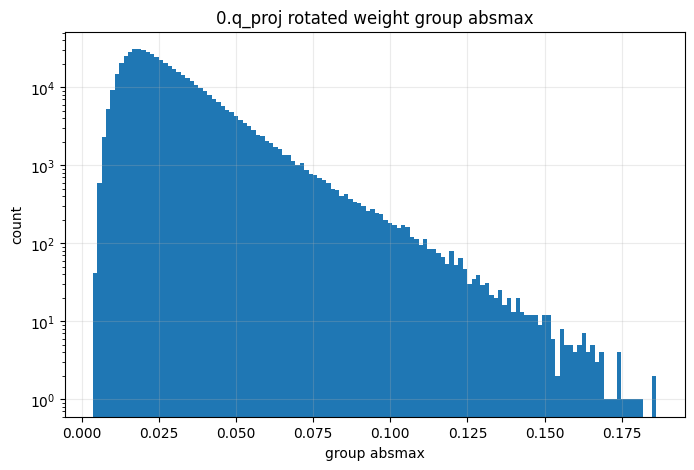

count    524288.000000
mean          0.028149
std           0.015599
min           0.003582
50%           0.024124
90%           0.047546
95%           0.058044
99%           0.085205
99.9%         0.122968
max           0.186279
dtype: float64

In [11]:
TARGET_LAYER = 0
TARGET_MODULE = "q_proj"

values = group_cache[(TARGET_LAYER, TARGET_MODULE)]["group_absmax"].flatten().numpy()
plt.figure(figsize=(8, 5))
plt.hist(values, bins=HIST_BINS)
plt.yscale("log")
plt.xlabel("group absmax")
plt.ylabel("count")
plt.title(f"{TARGET_LAYER}.{TARGET_MODULE} rotated weight group absmax")
plt.grid(True, alpha=0.25)
plt.show()

pd.Series(values).describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])

## absmax가 큰 group 확인

`row`는 output channel index, `group`은 input dimension을 `GROUP_SIZE`로 나눈 group index입니다. 실제 column 범위는 `[col_start, col_end)`입니다.

In [12]:
def top_groups(layer, module, top_k=20):
    data = group_cache[(layer, module)]
    absmax = data["group_absmax"]
    mean_abs = data["group_mean_abs"]
    std = data["group_std"]
    vals = absmax.flatten()
    k = min(top_k, vals.numel())
    top_vals, top_idx = torch.topk(vals, k=k)
    groups_per_row = absmax.shape[1]
    rows = []
    for rank, idx in enumerate(top_idx.tolist(), start=1):
        row = idx // groups_per_row
        group = idx % groups_per_row
        rows.append({
            "rank": rank,
            "row": row,
            "group": group,
            "col_start": group * GROUP_SIZE,
            "col_end": (group + 1) * GROUP_SIZE,
            "group_absmax": top_vals[rank - 1].item(),
            "group_mean_abs": mean_abs.flatten()[idx].item(),
            "group_std": std.flatten()[idx].item(),
        })
    return pd.DataFrame(rows)

top_groups(TARGET_LAYER, TARGET_MODULE, TOP_K)

,rank,row,group,col_start,col_end,group_absmax,group_mean_abs,group_std
0,1,3758,72,2304,2336,0.186279,0.043407,0.059277
1,2,3756,68,2176,2208,0.185669,0.041166,0.051249
2,3,3757,24,768,800,0.181274,0.046603,0.058655
3,4,3822,49,1568,1600,0.179443,0.052678,0.063158
4,5,3775,68,2176,2208,0.178711,0.039924,0.050142
5,6,3762,63,2016,2048,0.177612,0.040367,0.055609
6,7,3822,31,992,1024,0.176147,0.050414,0.062083
7,8,3767,97,3104,3136,0.174805,0.034590,0.045859
8,9,3775,40,1280,1312,0.174683,0.039616,0.053118
9,10,3758,24,768,800,0.173706,0.039164,0.053364


## Module별 histogram CSV 저장

각 module의 `group_absmax` histogram을 CSV로 저장합니다. 논문/보고서용 plot을 따로 그릴 때 쓰기 좋습니다.

In [13]:
hist_rows = []
for (layer, module), data in group_cache.items():
    vals = data["group_absmax"].flatten().numpy()
    counts, edges = pd.cut(vals, bins=HIST_BINS, retbins=True, include_lowest=True)
    count_series = pd.Series(counts).value_counts().sort_index()
    for i, interval in enumerate(count_series.index):
        hist_rows.append({
            "layer": layer,
            "module": module,
            "bin": i,
            "bin_start": float(interval.left),
            "bin_end": float(interval.right),
            "count": int(count_series.iloc[i]),
        })

hist_df = pd.DataFrame(hist_rows)
hist_csv = output_dir / "notebook_hist_group_absmax.csv"
hist_df.to_csv(hist_csv, index=False)
hist_csv

PosixPath('/home/irteam/shmin/SpinBFP/SpinQuant/bfp_runs/Llama-2-7b-hf/weight_distribution/R_4_4_4_FF/notebook_hist_group_absmax.csv')

In [27]:
TARGET_LAYER = 15
TARGET_MODULE = "q_proj"

data = group_cache[(TARGET_LAYER, TARGET_MODULE)]
absmax = data["group_absmax"]
mean_abs = data["group_mean_abs"]
std = data["group_std"]

rows = []
groups_per_row = absmax.shape[1]

for row_idx in range(absmax.shape[0]):
    for group_idx in range(groups_per_row):
        rows.append({
            "row": row_idx,
            "group": group_idx,
            "col_start": group_idx * GROUP_SIZE,
            "col_end": (group_idx + 1) * GROUP_SIZE,
            "group_absmax": absmax[row_idx, group_idx].item(),
            "group_mean_abs": mean_abs[row_idx, group_idx].item(),
            "group_std": std[row_idx, group_idx].item(),
        })

q_proj_l0_groups = pd.DataFrame(rows)
q_proj_l0_groups

,row,group,col_start,col_end,group_absmax,group_mean_abs,group_std
0,0,0,0,32,0.027481,0.009196,0.011417
1,0,1,32,64,0.035156,0.012061,0.014957
2,0,2,64,96,0.034363,0.010415,0.013002
3,0,3,96,128,0.026657,0.009206,0.011541
4,0,4,128,160,0.030014,0.011314,0.014254
...,...,...,...,...,...,...,...
524283,4095,123,3936,3968,0.086182,0.022134,0.027262
524284,4095,124,3968,4000,0.062012,0.020991,0.027573
524285,4095,125,4000,4032,0.075256,0.024394,0.029470
524286,4095,126,4032,4064,0.051392,0.025105,0.029167


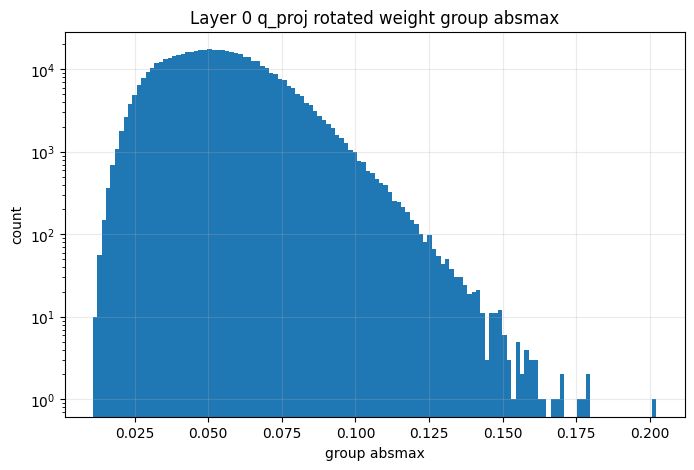

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(q_proj_l0_groups["group_absmax"], bins=128)
plt.yscale("log")
plt.xlabel("group absmax")
plt.ylabel("count")
plt.title("Layer 0 q_proj rotated weight group absmax")
plt.grid(True, alpha=0.25)
plt.show()

In [18]:
TARGET_LAYER = 0
TARGET_MODULE = "q_proj"

data = group_cache[(TARGET_LAYER, TARGET_MODULE)]
absmax = data["group_absmax"]
mean_abs = data["group_mean_abs"]
std = data["group_std"]

groups_per_row = absmax.shape[1]

rows = []
for idx in range(absmax.numel()):
    row = idx // groups_per_row
    group = idx % groups_per_row

    rows.append({
        "idx": idx,
        "row": row,
        "group": group,
        "col_start": group * GROUP_SIZE,
        "col_end": (group + 1) * GROUP_SIZE,
        "group_absmax": absmax.flatten()[idx].item(),
        "group_mean_abs": mean_abs.flatten()[idx].item(),
        "group_std": std.flatten()[idx].item(),
    })

q_proj_l0_by_idx = pd.DataFrame(rows)
q_proj_l0_by_idx

,idx,row,group,col_start,col_end,group_absmax,group_mean_abs,group_std
0,0,0,0,0,32,0.020432,0.006938,0.008552
1,1,0,1,32,64,0.018311,0.007239,0.008829
2,2,0,2,64,96,0.021210,0.008022,0.009927
3,3,0,3,96,128,0.015198,0.005605,0.006857
4,4,0,4,128,160,0.028427,0.009247,0.011086
...,...,...,...,...,...,...,...,...
524283,524283,4095,123,3936,3968,0.054321,0.016219,0.020133
524284,524284,4095,124,3968,4000,0.031860,0.012120,0.015406
524285,524285,4095,125,4000,4032,0.020401,0.007782,0.009473
524286,524286,4095,126,4032,4064,0.033051,0.013426,0.015870


In [20]:
TARGET_LAYER = 0
TARGET_MODULE = "q_proj"

# outlier 기준: 전체 group_absmax의 상위 1%
OUTLIER_Q = 0.99

data = group_cache[(TARGET_LAYER, TARGET_MODULE)]
absmax = data["group_absmax"]  # shape: [out_features, in_features / GROUP_SIZE]

threshold = torch.quantile(absmax.flatten(), OUTLIER_Q)

outlier_mask = absmax >= threshold
outlier_count_by_group = outlier_mask.sum(dim=0)
outlier_ratio_by_group = outlier_count_by_group.float() / absmax.shape[0]

group_outlier_df = pd.DataFrame({
    "group_idx": range(absmax.shape[1]),
    "col_start": [i * GROUP_SIZE for i in range(absmax.shape[1])],
    "col_end": [(i + 1) * GROUP_SIZE for i in range(absmax.shape[1])],
    "outlier_count": outlier_count_by_group.cpu().numpy(),
    "outlier_ratio": outlier_ratio_by_group.cpu().numpy(),
    "mean_absmax": absmax.mean(dim=0).cpu().numpy(),
    "max_absmax": absmax.max(dim=0).values.cpu().numpy(),
    "p99_absmax": torch.quantile(absmax.float(), 0.99, dim=0).cpu().numpy(),
})

group_outlier_df.sort_values(
    ["outlier_count", "max_absmax"],
    ascending=False,
).head(50)

,group_idx,col_start,col_end,outlier_count,outlier_ratio,mean_absmax,max_absmax,p99_absmax
24,24,768,800,69,0.016846,0.028258,0.181274,0.100357
68,68,2176,2208,64,0.015625,0.028973,0.185669,0.094986
64,64,2048,2080,63,0.015381,0.027901,0.172119,0.096933
124,124,3968,4000,57,0.013916,0.027649,0.160400,0.089478
87,87,2784,2816,54,0.013184,0.029028,0.150024,0.091019
63,63,2016,2048,53,0.012939,0.030214,0.177612,0.093527
59,59,1888,1920,53,0.012939,0.028857,0.149536,0.090039
76,76,2432,2464,53,0.012939,0.028586,0.143677,0.090274
97,97,3104,3136,52,0.012695,0.029455,0.174805,0.092108
85,85,2720,2752,52,0.012695,0.028542,0.162842,0.090173
